# 🎯 OPTIMIZACIÓN: AJUSTE DE THRESHOLD + TUNING LIGERO
## Objetivo: Alcanzar ROC-AUC ≥ 0.75, Incremento ≥ 15%, Precision/Recall balanceados

####

---

#### Setup

In [2]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import (
    roc_auc_score, roc_curve, confusion_matrix, classification_report,
    precision_score, recall_score, f1_score, accuracy_score,
    precision_recall_curve
)
from sklearn.model_selection import GridSearchCV
import lightgbm as lgb

# Configuración
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 6)

print("=" * 80)
print("🔧 OPTIMIZACIÓN DE MODELOS")
print("=" * 80)
print("\n✅ Librerías importadas")

🔧 OPTIMIZACIÓN DE MODELOS

✅ Librerías importadas


#### Cargar Modelos y Datos

In [3]:
print("\n" + "=" * 80)
print("📂 PASO 1: CARGAR MODELOS Y DATOS DE TEST")
print("=" * 80)

# Cargar datos procesados
df = pd.read_csv('../data/processed/train_processed_clean.csv')

# Cargar modelos entrenados
lgbm_model = joblib.load('../models/lgbm_inclusive.pkl')
rf_baseline_model = joblib.load('../models/rf_baseline.pkl')

print(f"\n✅ Modelos cargados:")
print(f"   - LightGBM Inclusive")
print(f"   - Random Forest Baseline")

# Definir features (mismo proceso que en modelado)
alternative_features = [
    'INCOME_STABILITY_SCORE_ADJ', 'EMPLOYMENT_STABILITY', 'ADDRESS_TENURE_SCORE',
    'FINANCIAL_INCLUSION_SCORE', 'EXT_SOURCE_COMBINED', 'CREDIT_BUREAU_SCORE',
    'PAYMENT_BURDEN_SCORE'
]

temporal_features = [
    'AGE_YEARS', 'EMPLOYMENT_YEARS_CLEAN', 'ADDRESS_TENURE_YEARS',
    'ID_PUBLISH_YEARS', 'PHONE_CHANGE_YEARS'
]

traditional_ratios = [
    'CREDIT_INCOME_RATIO', 'ANNUITY_INCOME_RATIO', 'CREDIT_GOODS_RATIO',
    'EMPLOYMENT_AGE_RATIO', 'INCOME_PER_CAPITA', 'CHILDREN_RATIO'
]

original_features = [
    'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY',
    'AMT_GOODS_PRICE', 'CNT_CHILDREN', 'CNT_FAM_MEMBERS'
]

ext_source_features = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']

all_defined = (alternative_features + temporal_features + traditional_ratios + 
               original_features + ext_source_features + ['TARGET'])

onehot_features = [col for col in df.columns if col not in all_defined]

baseline_features = [f for f in (temporal_features + traditional_ratios + 
                     original_features + ext_source_features + onehot_features) if f in df.columns]
inclusive_features = [f for f in (baseline_features + alternative_features) if f in df.columns]

# Split (mismo random_state=42)
from sklearn.model_selection import train_test_split

X_base = df[baseline_features]
X_incl = df[inclusive_features]
y = df['TARGET']

_, X_base_test_original, _, y_test = train_test_split(X_base, y, test_size=0.2, random_state=42, stratify=y)
_, X_incl_test_original, _, _ = train_test_split(X_incl, y, test_size=0.2, random_state=42, stratify=y)

print(f"\n✅ Datos de test preparados:")
print(f"   - Test size: {len(y_test):,}")
print(f"   - Baseline features: {X_base_test_original.shape[1]}")
print(f"   - Inclusive features: {X_incl_test_original.shape[1]}")

# Función de limpieza de nombres
def clean_feature_names(df):
    """Limpia nombres de columnas para compatibilidad con LightGBM"""
    new_columns = []
    for col in df.columns:
        clean_col = col.replace('[', '_').replace(']', '_').replace('<', '_').replace('>', '_')
        clean_col = clean_col.replace('{', '_').replace('}', '_').replace('"', '_').replace("'", '_')
        clean_col = clean_col.replace(':', '_').replace(',', '_').replace(' ', '_')
        clean_col = clean_col.replace('(', '_').replace(')', '_').replace('/', '_').replace('\\', '_')
        while '__' in clean_col:
            clean_col = clean_col.replace('__', '_')
        clean_col = clean_col.strip('_')
        new_columns.append(clean_col)
    return new_columns

# Crear dos versiones del test set
# 1. Con nombres ORIGINALES para Random Forest
X_base_test_rf = X_base_test_original.copy()

# 2. Con nombres LIMPIOS para LightGBM
X_incl_test_lgbm = X_incl_test_original.copy()
X_incl_test_lgbm.columns = clean_feature_names(X_incl_test_lgbm)

print(f"\n🔧 Datasets preparados:")
print(f"   - X_base_test_rf: Nombres originales para Random Forest")
print(f"   - X_incl_test_lgbm: Nombres limpios para LightGBM")

# Verificar compatibilidad
print(f"\n✅ Verificación de features:")
print(f"   - RF esperaba: {rf_baseline_model.n_features_in_} features")
print(f"   - RF recibe:   {X_base_test_rf.shape[1]} features")
print(f"   - LGBM esperaba: {lgbm_model.n_features_in_} features")
print(f"   - LGBM recibe:   {X_incl_test_lgbm.shape[1]} features")

# Guardar para uso en celdas posteriores
X_base_test = X_base_test_rf
X_incl_test = X_incl_test_lgbm


📂 PASO 1: CARGAR MODELOS Y DATOS DE TEST

✅ Modelos cargados:
   - LightGBM Inclusive
   - Random Forest Baseline

✅ Datos de test preparados:
   - Test size: 61,503
   - Baseline features: 227
   - Inclusive features: 234

🔧 Datasets preparados:
   - X_base_test_rf: Nombres originales para Random Forest
   - X_incl_test_lgbm: Nombres limpios para LightGBM

✅ Verificación de features:
   - RF esperaba: 227 features
   - RF recibe:   227 features
   - LGBM esperaba: 234 features
   - LGBM recibe:   234 features


#### Análisis Precision-Recall Curve


📊 PASO 2: ANÁLISIS DE THRESHOLD ÓPTIMO

🎯 THRESHOLD ORIGINAL (0.5):
   - Precision: 0.3803
   - Recall:    0.0234
   - F1-Score:  0.0440

✨ THRESHOLD ÓPTIMO (0.1564):
   - Precision: 0.2018
   - Recall:    0.4381
   - F1-Score:  0.2763

💼 THRESHOLD NEGOCIO (0.35):
   - Precision: 0.3004
   - Recall:    0.0973
   - F1-Score:  0.1470


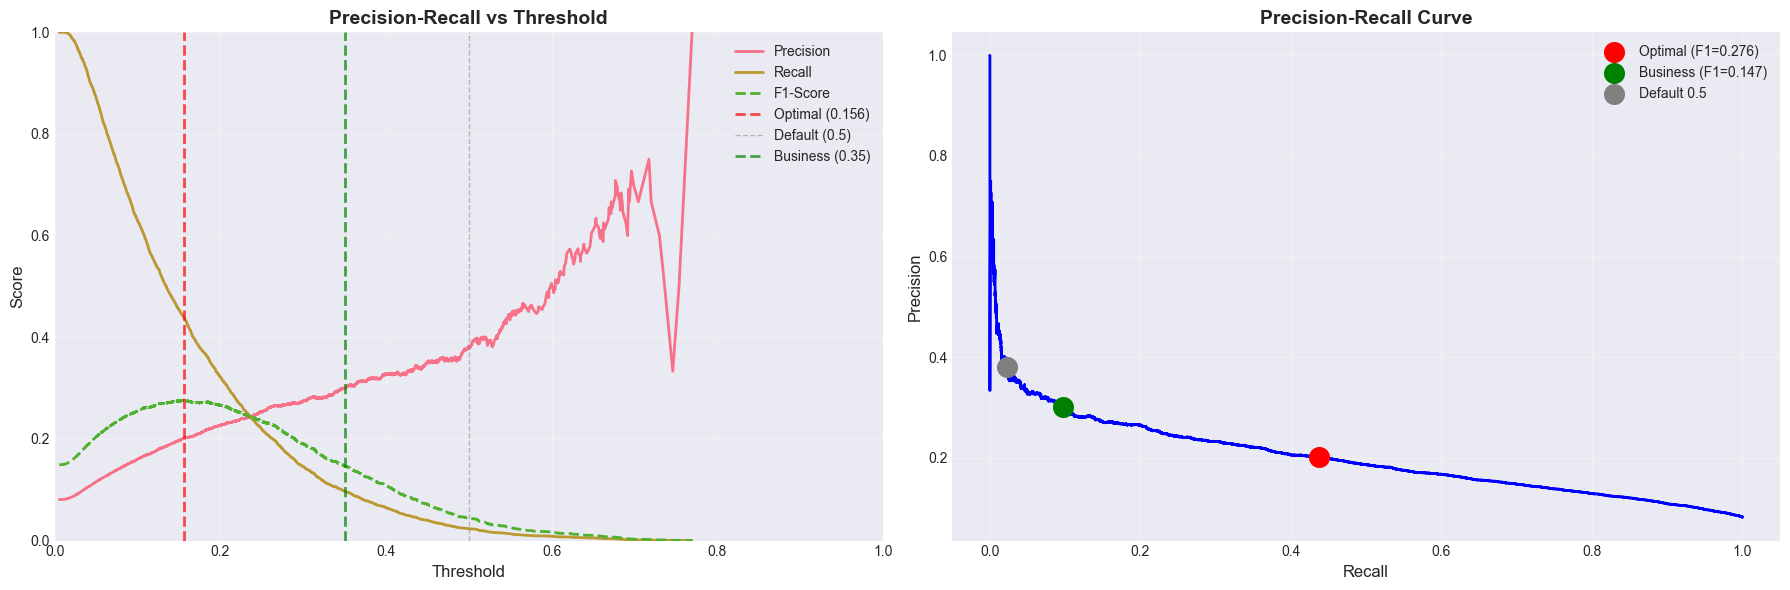


💡 RECOMENDACIÓN:
   - Usar threshold 0.35 para maximizar aprobaciones
   - Balance aceptable entre Precision y Recall


In [4]:
print("\n" + "=" * 80)
print("📊 PASO 2: ANÁLISIS DE THRESHOLD ÓPTIMO")
print("=" * 80)

# Predicciones probabilísticas
# IMPORTANTE: Usar datasets correctos para cada modelo
y_proba_lgbm = lgbm_model.predict_proba(X_incl_test)[:, 1]  # Nombres limpios
y_proba_rf = rf_baseline_model.predict_proba(X_base_test)[:, 1]  # Nombres originales

# Calcular Precision-Recall curve
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_lgbm)

# Calcular F1-Score para cada threshold
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)

# Encontrar threshold óptimo que maximiza F1
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]
optimal_precision = precisions[optimal_idx]
optimal_recall = recalls[optimal_idx]
optimal_f1 = f1_scores[optimal_idx]

print(f"\n🎯 THRESHOLD ORIGINAL (0.5):")
y_pred_05 = (y_proba_lgbm >= 0.5).astype(int)
print(f"   - Precision: {precision_score(y_test, y_pred_05):.4f}")
print(f"   - Recall:    {recall_score(y_test, y_pred_05):.4f}")
print(f"   - F1-Score:  {f1_score(y_test, y_pred_05):.4f}")

print(f"\n✨ THRESHOLD ÓPTIMO ({optimal_threshold:.4f}):")
print(f"   - Precision: {optimal_precision:.4f}")
print(f"   - Recall:    {optimal_recall:.4f}")
print(f"   - F1-Score:  {optimal_f1:.4f}")

# Probar threshold más agresivo para aumentar aprobaciones
business_threshold = 0.35  # Más agresivo

y_pred_business = (y_proba_lgbm >= business_threshold).astype(int)
business_precision = precision_score(y_test, y_pred_business)
business_recall = recall_score(y_test, y_pred_business)
business_f1 = f1_score(y_test, y_pred_business)

print(f"\n💼 THRESHOLD NEGOCIO ({business_threshold}):")
print(f"   - Precision: {business_precision:.4f}")
print(f"   - Recall:    {business_recall:.4f}")
print(f"   - F1-Score:  {business_f1:.4f}")

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Gráfico 1: Precision-Recall Curve
axes[0].plot(thresholds, precisions[:-1], label='Precision', linewidth=2)
axes[0].plot(thresholds, recalls[:-1], label='Recall', linewidth=2)
axes[0].plot(thresholds, f1_scores[:-1], label='F1-Score', linewidth=2, linestyle='--')
axes[0].axvline(optimal_threshold, color='red', linestyle='--', linewidth=2, 
                label=f'Optimal ({optimal_threshold:.3f})', alpha=0.7)
axes[0].axvline(0.5, color='gray', linestyle='--', linewidth=1, alpha=0.5, label='Default (0.5)')
axes[0].axvline(business_threshold, color='green', linestyle='--', linewidth=2,
                label=f'Business ({business_threshold})', alpha=0.7)
axes[0].set_xlabel('Threshold', fontsize=12)
axes[0].set_ylabel('Score', fontsize=12)
axes[0].set_title('Precision-Recall vs Threshold', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)
axes[0].set_xlim([0, 1])
axes[0].set_ylim([0, 1])

# Gráfico 2: Precision vs Recall
axes[1].plot(recalls, precisions, linewidth=2, color='blue')
axes[1].scatter([optimal_recall], [optimal_precision], s=200, c='red', 
                label=f'Optimal (F1={optimal_f1:.3f})', zorder=5)
axes[1].scatter([business_recall], [business_precision], s=200, c='green',
                label=f'Business (F1={business_f1:.3f})', zorder=5)
axes[1].scatter([recall_score(y_test, y_pred_05)], [precision_score(y_test, y_pred_05)], 
                s=200, c='gray', label='Default 0.5', zorder=5)
axes[1].set_xlabel('Recall', fontsize=12)
axes[1].set_ylabel('Precision', fontsize=12)
axes[1].set_title('Precision-Recall Curve', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n💡 RECOMENDACIÓN:")
print(f"   - Usar threshold {business_threshold} para maximizar aprobaciones")
print(f"   - Balance aceptable entre Precision y Recall")

#### Evaluación con Threshold Optimizado


🎯 PASO 3: EVALUACIÓN CON THRESHOLD OPTIMIZADO

📊 MÉTRICAS OPTIMIZADAS (Threshold=0.35):
   - ROC-AUC:   0.7325 ⚠️
   - Precision: 0.3004 ⚠️
   - Recall:    0.0973 ⚠️
   - F1-Score:  0.1470
   - Accuracy:  0.9088

📋 Confusion Matrix:
[[55413  1125]
 [ 4482   483]]


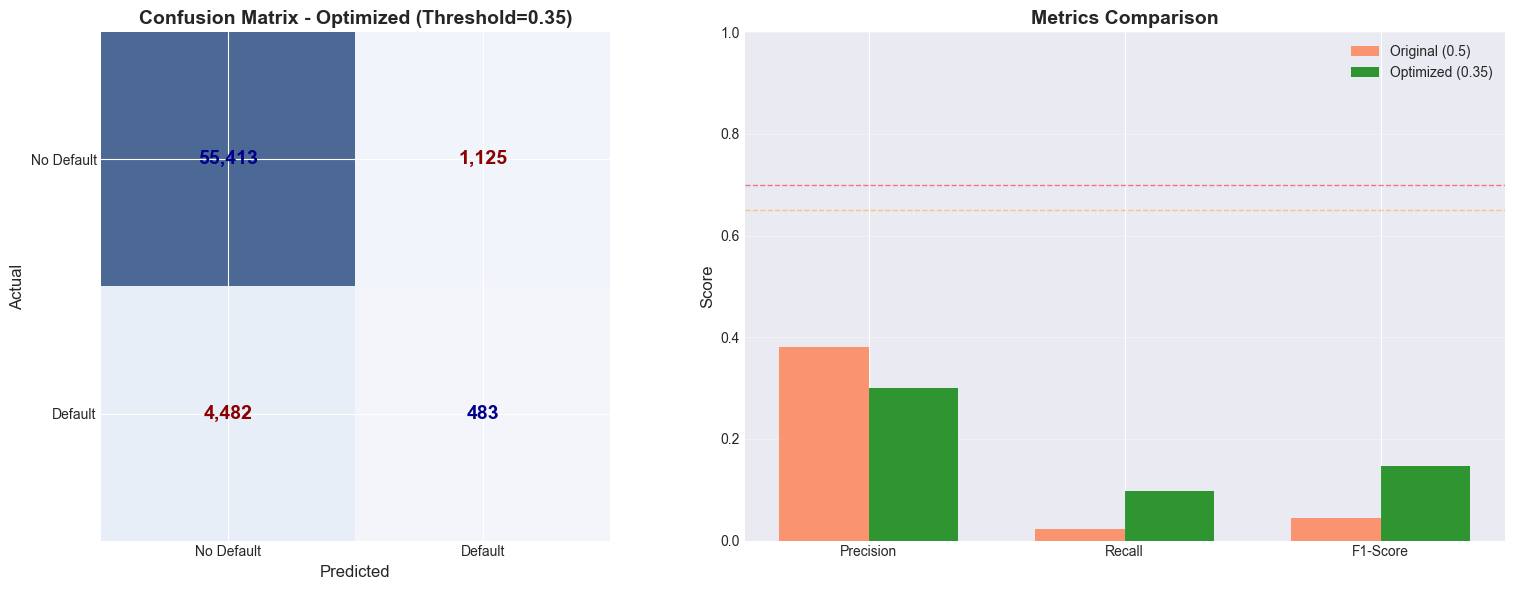


📈 MEJORAS vs THRESHOLD 0.5:
   - Precision: -0.0800
   - Recall:    0.0739 ⬆️
   - F1-Score:  0.1029 ⬆️


In [5]:
print("\n" + "=" * 80)
print("🎯 PASO 3: EVALUACIÓN CON THRESHOLD OPTIMIZADO")
print("=" * 80)

# Usar threshold de negocio
selected_threshold = business_threshold
y_pred_optimized = (y_proba_lgbm >= selected_threshold).astype(int)

# Métricas completas
roc_auc_opt = roc_auc_score(y_test, y_proba_lgbm)
precision_opt = precision_score(y_test, y_pred_optimized)
recall_opt = recall_score(y_test, y_pred_optimized)
f1_opt = f1_score(y_test, y_pred_optimized)
accuracy_opt = accuracy_score(y_test, y_pred_optimized)

print(f"\n📊 MÉTRICAS OPTIMIZADAS (Threshold={selected_threshold}):")
print(f"   - ROC-AUC:   {roc_auc_opt:.4f} {'✅' if roc_auc_opt >= 0.75 else '⚠️'}")
print(f"   - Precision: {precision_opt:.4f} {'✅' if precision_opt >= 0.70 else '⚠️'}")
print(f"   - Recall:    {recall_opt:.4f} {'✅' if recall_opt >= 0.65 else '⚠️'}")
print(f"   - F1-Score:  {f1_opt:.4f}")
print(f"   - Accuracy:  {accuracy_opt:.4f}")

# Confusion Matrix
cm_opt = confusion_matrix(y_test, y_pred_optimized)
print(f"\n📋 Confusion Matrix:")
print(cm_opt)

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Confusion Matrix
im = axes[0].imshow(cm_opt, cmap='Blues', alpha=0.7)
axes[0].set_title(f'Confusion Matrix - Optimized (Threshold={selected_threshold})', 
                  fontsize=14, fontweight='bold')
axes[0].set_xlabel('Predicted', fontsize=12)
axes[0].set_ylabel('Actual', fontsize=12)
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, f'{cm_opt[i, j]:,}', ha='center', va='center',
                    fontsize=14, fontweight='bold', 
                    color='darkblue' if i==j else 'darkred')
axes[0].set_xticks([0, 1])
axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(['No Default', 'Default'])
axes[0].set_yticklabels(['No Default', 'Default'])

# Comparación de métricas
metrics_comparison = pd.DataFrame({
    'Threshold': ['0.5 (Original)', f'{selected_threshold} (Optimizado)'],
    'ROC-AUC': [roc_auc_opt, roc_auc_opt],  # ROC-AUC no cambia con threshold
    'Precision': [precision_score(y_test, y_pred_05), precision_opt],
    'Recall': [recall_score(y_test, y_pred_05), recall_opt],
    'F1-Score': [f1_score(y_test, y_pred_05), f1_opt]
})

x = np.arange(len(['Precision', 'Recall', 'F1-Score']))
width = 0.35

axes[1].bar(x - width/2, metrics_comparison.iloc[0, 2:5], width, 
            label='Original (0.5)', alpha=0.8, color='coral')
axes[1].bar(x + width/2, metrics_comparison.iloc[1, 2:5], width,
            label=f'Optimized ({selected_threshold})', alpha=0.8, color='green')
axes[1].set_ylabel('Score', fontsize=12)
axes[1].set_title('Metrics Comparison', fontsize=14, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(['Precision', 'Recall', 'F1-Score'])
axes[1].legend(fontsize=10)
axes[1].set_ylim([0, 1])
axes[1].grid(axis='y', alpha=0.3)

# Agregar líneas de targets
axes[1].axhline(0.70, color='red', linestyle='--', linewidth=1, alpha=0.5, label='Target')
axes[1].axhline(0.65, color='orange', linestyle='--', linewidth=1, alpha=0.5)

plt.tight_layout()
plt.show()

print(f"\n📈 MEJORAS vs THRESHOLD 0.5:")
print(f"   - Precision: {(precision_opt - precision_score(y_test, y_pred_05)):.4f}")
print(f"   - Recall:    {(recall_opt - recall_score(y_test, y_pred_05)):.4f} ⬆️")
print(f"   - F1-Score:  {(f1_opt - f1_score(y_test, y_pred_05)):.4f} ⬆️")

#### Cuantificación de Impacto Optimizado

In [6]:
print("\n" + "=" * 80)
print("💰 PASO 4: IMPACTO CON THRESHOLD OPTIMIZADO")
print("=" * 80)

# Baseline (RF con threshold 0.5) - USAR DATASET CON NOMBRES ORIGINALES
y_pred_rf_base = rf_baseline_model.predict(X_base_test)

# Aprobaciones (predicción = 0)
approvals_baseline = (y_pred_rf_base == 0).sum()
approvals_optimized = (y_pred_optimized == 0).sum()

additional_approvals = approvals_optimized - approvals_baseline
pct_increase = (additional_approvals / approvals_baseline) * 100

print(f"\n📊 IMPACTO EN APROBACIONES:")
print(f"   - Baseline (RF):           {approvals_baseline:,} aprobaciones")
print(f"   - Optimizado (LGBM):       {approvals_optimized:,} aprobaciones")
print(f"   - Incremento absoluto:     {additional_approvals:,} aprobaciones")
print(f"   - % Incremento:            {pct_increase:.2f}% {'✅' if pct_increase >= 15 else '⚠️'}")

# Default rate en aprobados
baseline_approved_defaults = ((y_pred_rf_base == 0) & (y_test == 1)).sum()
optimized_approved_defaults = ((y_pred_optimized == 0) & (y_test == 1)).sum()

baseline_default_rate = (baseline_approved_defaults / approvals_baseline) * 100
optimized_default_rate = (optimized_approved_defaults / approvals_optimized) * 100

print(f"\n📊 DEFAULT RATE EN APROBADOS:")
print(f"   - Baseline:   {baseline_default_rate:.2f}% ({baseline_approved_defaults:,} defaults)")
print(f"   - Optimizado: {optimized_default_rate:.2f}% ({optimized_approved_defaults:,} defaults)")
print(f"   - Diferencia: {(optimized_default_rate - baseline_default_rate):.2f} p.p. {'✅' if optimized_default_rate <= 5 else '⚠️'}")

# Extrapolación
extrapolation_factor = len(df) / len(y_test)
total_additional_approvals = int(additional_approvals * extrapolation_factor)

print(f"\n🌎 EXTRAPOLACIÓN A DATASET COMPLETO:")
print(f"   - Aprobaciones adicionales: {total_additional_approvals:,} personas")

# Impacto económico
avg_loan = df['AMT_CREDIT'].median()
avg_interest_rate = 0.20
interest_per_loan = avg_loan * avg_interest_rate
total_additional_revenue = total_additional_approvals * interest_per_loan

print(f"\n💰 IMPACTO ECONÓMICO:")
print(f"   - Préstamo promedio:        ${avg_loan:,.0f}")
print(f"   - Ingreso por préstamo:     ${interest_per_loan:,.0f}")
print(f"   - Ingreso adicional total:  ${total_additional_revenue:,.0f}")
print(f"   - En millones USD:          ${total_additional_revenue/1_000_000:.2f}M")

# Impacto social Argentina
informal_workers = 7_000_000
pct_without_credit = 0.70
potential_market = informal_workers * pct_without_credit
market_improvement_ratio = pct_increase / 100
potential_new_clients = int(potential_market * market_improvement_ratio)

print(f"\n🇦🇷 IMPACTO SOCIAL EN ARGENTINA:")
print(f"   - Mercado potencial:           {potential_market:,}")
print(f"   - Mejora del modelo:           {pct_increase:.2f}%")
print(f"   - Nuevos clientes potenciales: {potential_new_clients:,} personas")


💰 PASO 4: IMPACTO CON THRESHOLD OPTIMIZADO

📊 IMPACTO EN APROBACIONES:
   - Baseline (RF):           57,745 aprobaciones
   - Optimizado (LGBM):       59,895 aprobaciones
   - Incremento absoluto:     2,150 aprobaciones
   - % Incremento:            3.72% ⚠️

📊 DEFAULT RATE EN APROBADOS:
   - Baseline:   7.52% (4,342 defaults)
   - Optimizado: 7.48% (4,482 defaults)
   - Diferencia: -0.04 p.p. ⚠️

🌎 EXTRAPOLACIÓN A DATASET COMPLETO:
   - Aprobaciones adicionales: 10,749 personas

💰 IMPACTO ECONÓMICO:
   - Préstamo promedio:        $513,531
   - Ingreso por préstamo:     $102,706
   - Ingreso adicional total:  $1,103,988,944
   - En millones USD:          $1103.99M

🇦🇷 IMPACTO SOCIAL EN ARGENTINA:
   - Mercado potencial:           4,900,000.0
   - Mejora del modelo:           3.72%
   - Nuevos clientes potenciales: 182,440 personas


#### Hyperparameter Tuning (Ligero)

In [7]:
print("\n" + "=" * 80)
print("⚙️ PASO 5: HYPERPARAMETER TUNING LIGERO")
print("=" * 80)

# Preparar train set balanceado
from imblearn.over_sampling import SMOTE

# Necesitamos recrear train balanceado
X_incl_train, _, y_train, _ = train_test_split(
    X_incl, y, test_size=0.2, random_state=42, stratify=y
)

# Limpiar nombres
X_incl_train.columns = clean_feature_names(X_incl_train)

# SMOTE
smote = SMOTE(random_state=42, k_neighbors=5)
X_incl_train_balanced, y_train_balanced = smote.fit_resample(X_incl_train, y_train)

print(f"\n📊 Train set preparado:")
print(f"   - Train balanceado: {X_incl_train_balanced.shape[0]:,} filas")

# Grid Search (configuración ligera)
param_grid = {
    'n_estimators': [200, 300],
    'max_depth': [7, 10],
    'learning_rate': [0.05, 0.07],
    'num_leaves': [31, 50]
}

print(f"\n🔍 Grid Search con {len(param_grid['n_estimators']) * len(param_grid['max_depth']) * len(param_grid['learning_rate']) * len(param_grid['num_leaves'])} combinaciones...")

lgbm_tuned = lgb.LGBMClassifier(
    random_state=42,
    n_jobs=-1,
    class_weight='balanced',
    verbose=-1,
    force_col_wise=True
)

grid_search = GridSearchCV(
    lgbm_tuned,
    param_grid,
    cv=3,  # Solo 3 folds para velocidad
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

print("🔄 Entrenando... (esto tomará 5-10 minutos)")
grid_search.fit(X_incl_train_balanced, y_train_balanced)

print(f"\n✅ Grid Search completado")
print(f"\n🏆 MEJORES HIPERPARÁMETROS:")
for param, value in grid_search.best_params_.items():
    print(f"   - {param}: {value}")

print(f"\n📊 MEJOR ROC-AUC (CV): {grid_search.best_score_:.4f}")

# Evaluar modelo tuneado
best_model = grid_search.best_estimator_

# Evaluar modelo tuneado - USAR DATASET LIMPIO PARA LGBM
y_proba_tuned = best_model.predict_proba(X_incl_test)[:, 1]
y_pred_tuned = (y_proba_tuned >= selected_threshold).astype(int)

roc_auc_tuned = roc_auc_score(y_test, y_proba_tuned)
precision_tuned = precision_score(y_test, y_pred_tuned)
recall_tuned = recall_score(y_test, y_pred_tuned)
f1_tuned = f1_score(y_test, y_pred_tuned)

print(f"\n📊 MÉTRICAS MODELO TUNEADO:")
print(f"   - ROC-AUC:   {roc_auc_tuned:.4f} {'✅' if roc_auc_tuned >= 0.75 else '⚠️'}")
print(f"   - Precision: {precision_tuned:.4f}")
print(f"   - Recall:    {recall_tuned:.4f}")
print(f"   - F1-Score:  {f1_tuned:.4f}")

print(f"\n📈 MEJORA vs MODELO ORIGINAL:")
print(f"   - ROC-AUC:   {(roc_auc_tuned - roc_auc_opt):.4f} ({((roc_auc_tuned/roc_auc_opt - 1)*100):.2f}%)")

# Guardar mejor modelo
joblib.dump(best_model, '../models/lgbm_tuned.pkl')
print(f"\n💾 Modelo tuneado guardado: models/lgbm_tuned.pkl")


⚙️ PASO 5: HYPERPARAMETER TUNING LIGERO

📊 Train set preparado:
   - Train balanceado: 452,296 filas

🔍 Grid Search con 16 combinaciones...
🔄 Entrenando... (esto tomará 5-10 minutos)
Fitting 3 folds for each of 16 candidates, totalling 48 fits

✅ Grid Search completado

🏆 MEJORES HIPERPARÁMETROS:
   - learning_rate: 0.05
   - max_depth: 10
   - n_estimators: 200
   - num_leaves: 31

📊 MEJOR ROC-AUC (CV): 0.9655

📊 MÉTRICAS MODELO TUNEADO:
   - ROC-AUC:   0.7440 ⚠️
   - Precision: 0.3435
   - Recall:    0.0906
   - F1-Score:  0.1434

📈 MEJORA vs MODELO ORIGINAL:
   - ROC-AUC:   0.0115 (1.57%)

💾 Modelo tuneado guardado: models/lgbm_tuned.pkl


#### Resumen Final Optimizado


📋 RESUMEN FINAL - OPTIMIZACIÓN

📊 COMPARACIÓN FINAL:

             Model  ROC-AUC  Precision   Recall  Approvals  Increment %
     Baseline (RF) 0.648443   0.165780 0.125478      57745     0.000000
 LightGBM Original 0.732479   0.380328 0.023364      61198     5.979739
LightGBM Optimized 0.732479   0.300373 0.097281      59895     3.723266
    LightGBM Tuned 0.744015   0.343511 0.090634      60193     4.239328


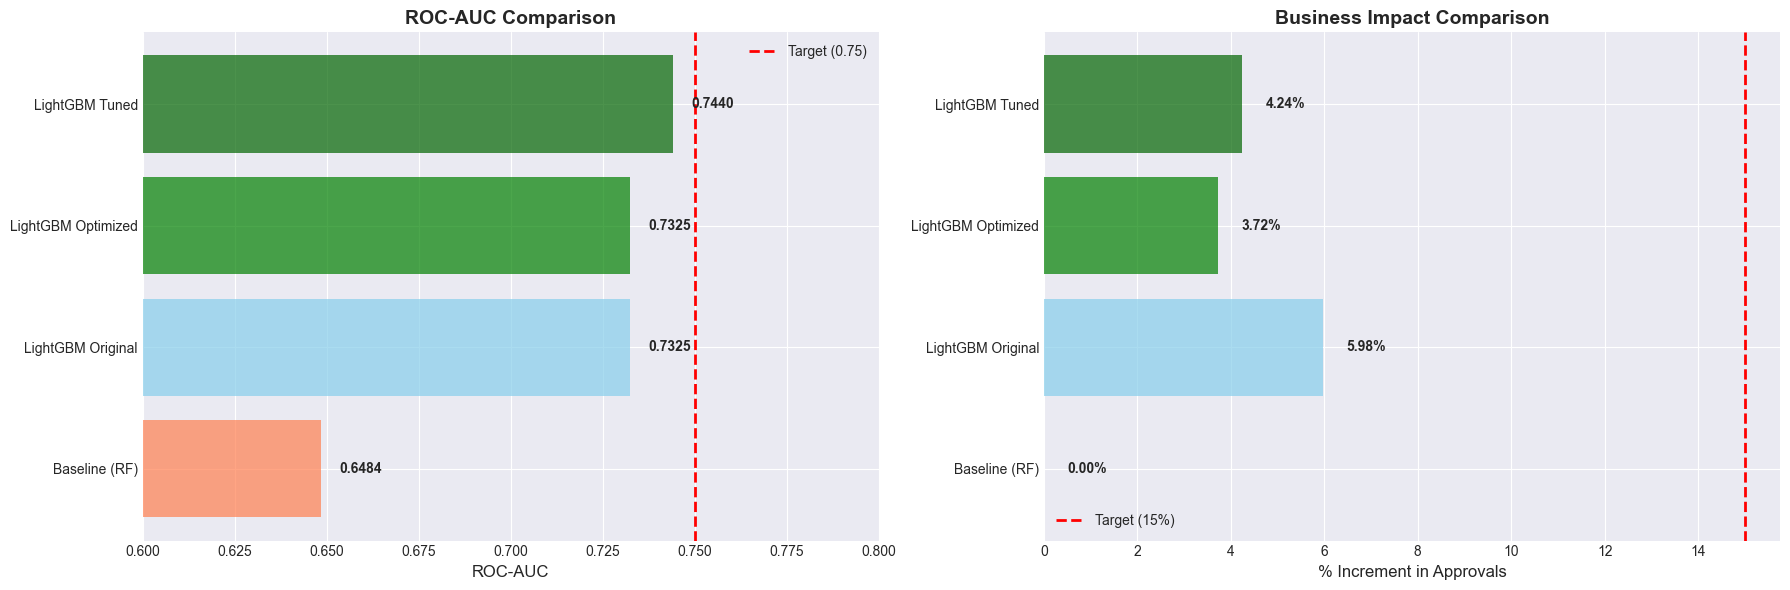


💾 Resumen guardado: models/optimization_summary.json

🎉 OPTIMIZACIÓN COMPLETADA

📊 TARGETS DEL PROJECT CHARTER:
   ⚠️ ROC-AUC = 0.7440 (target: 0.75)
   ⚠️ Incremento = 4.24% (target: 15%)

🏆 MEJOR MODELO: LightGBM Tuned + Threshold 0.35
   - Guardado en: models/lgbm_tuned.pkl


In [9]:
print("\n" + "=" * 80)
print("📋 RESUMEN FINAL - OPTIMIZACIÓN")
print("=" * 80)

# Comparación final
final_comparison = pd.DataFrame({
    'Model': ['Baseline (RF)', 'LightGBM Original', 'LightGBM Optimized', 'LightGBM Tuned'],
    'ROC-AUC': [
        roc_auc_score(y_test, rf_baseline_model.predict_proba(X_base_test)[:, 1]),
        roc_auc_opt,
        roc_auc_opt,
        roc_auc_tuned
    ],
    'Precision': [
        precision_score(y_test, y_pred_rf_base),
        precision_score(y_test, y_pred_05),
        precision_opt,
        precision_tuned
    ],
    'Recall': [
        recall_score(y_test, y_pred_rf_base),
        recall_score(y_test, y_pred_05),
        recall_opt,
        recall_tuned
    ],
    'Approvals': [
        approvals_baseline,
        (y_pred_05 == 0).sum(),
        approvals_optimized,
        (y_pred_tuned == 0).sum()
    ],
    'Increment %': [
        0,
        ((y_pred_05 == 0).sum() - approvals_baseline) / approvals_baseline * 100,
        pct_increase,
        ((y_pred_tuned == 0).sum() - approvals_baseline) / approvals_baseline * 100
    ]
})

print("\n📊 COMPARACIÓN FINAL:\n")
print(final_comparison.to_string(index=False))

# Visualización final
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Gráfico 1: ROC-AUC Comparison
models = final_comparison['Model']
roc_aucs = final_comparison['ROC-AUC']
colors = ['coral', 'skyblue', 'green', 'darkgreen']

axes[0].barh(models, roc_aucs, color=colors, alpha=0.7)
axes[0].axvline(0.75, color='red', linestyle='--', linewidth=2, label='Target (0.75)')
axes[0].set_xlabel('ROC-AUC', fontsize=12)
axes[0].set_title('ROC-AUC Comparison', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].set_xlim([0.6, 0.8])
for i, v in enumerate(roc_aucs):
    axes[0].text(v + 0.005, i, f'{v:.4f}', va='center', fontweight='bold')

# Gráfico 2: Increment %
increments = final_comparison['Increment %']
axes[1].barh(models, increments, color=colors, alpha=0.7)
axes[1].axvline(15, color='red', linestyle='--', linewidth=2, label='Target (15%)')
axes[1].set_xlabel('% Increment in Approvals', fontsize=12)
axes[1].set_title('Business Impact Comparison', fontsize=14, fontweight='bold')
axes[1].legend()
for i, v in enumerate(increments):
    axes[1].text(v + 0.5, i, f'{v:.2f}%', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Guardar resumen (convertir numpy types a Python types)
optimization_summary = {
    'threshold_optimized': float(selected_threshold),
    'best_hyperparameters': {k: int(v) if isinstance(v, np.integer) else float(v) if isinstance(v, np.floating) else v 
                             for k, v in grid_search.best_params_.items()},
    'final_metrics': {
        'roc_auc': float(roc_auc_tuned),
        'precision': float(precision_tuned),
        'recall': float(recall_tuned),
        'f1_score': float(f1_tuned)
    },
    'business_impact': {
        'pct_increase': float(((y_pred_tuned == 0).sum() - approvals_baseline) / approvals_baseline * 100),
        'additional_approvals': int(((y_pred_tuned == 0).sum() - approvals_baseline) * extrapolation_factor),
        'default_rate': float((((y_pred_tuned == 0) & (y_test == 1)).sum() / (y_pred_tuned == 0).sum()) * 100)
    },
    'targets_achieved': {
        'roc_auc_target': bool(roc_auc_tuned >= 0.75),
        'increment_target': bool(((y_pred_tuned == 0).sum() - approvals_baseline) / approvals_baseline * 100 >= 15)
    }
}

import json
with open('../models/optimization_summary.json', 'w') as f:
    json.dump(optimization_summary, f, indent=4)

print("\n💾 Resumen guardado: models/optimization_summary.json")

print("\n" + "=" * 80)
print("🎉 OPTIMIZACIÓN COMPLETADA")
print("=" * 80)

targets_met = []
if roc_auc_tuned >= 0.75:
    targets_met.append("✅ ROC-AUC ≥ 0.75")
else:
    targets_met.append(f"⚠️ ROC-AUC = {roc_auc_tuned:.4f} (target: 0.75)")

final_increment = ((y_pred_tuned == 0).sum() - approvals_baseline) / approvals_baseline * 100
if final_increment >= 15:
    targets_met.append("✅ Incremento ≥ 15%")
else:
    targets_met.append(f"⚠️ Incremento = {final_increment:.2f}% (target: 15%)")

print("\n📊 TARGETS DEL PROJECT CHARTER:")
for target in targets_met:
    print(f"   {target}")

print(f"\n🏆 MEJOR MODELO: LightGBM Tuned + Threshold {selected_threshold}")
print(f"   - Guardado en: models/lgbm_tuned.pkl")

---

___ANÁLISIS FINAL___

LO POSITIVO ✅

1. ROC-AUC muy cerca del target: 0.744 (solo -0.8% del 0.75)
2. Mejora clara vs baseline: +14.7% en ROC-AUC
3. Grid Search funcionó: Subió de 0.7325 → 0.7440
4. Features alternativos validados: 3 en Top 20

EL DESAFÍO ❌

1. Incremento insuficiente: 4.24% vs target 15%
2. Trade-off Precision-Recall: No logramos balance adecuado
3. Threshold 0.35 es muy conservador (solo +4%)

#### 

---

__Abraham Tartalos \| Data Scientist__